<a href="https://colab.research.google.com/github/vardhamanadarsh/Stock-price-prediction-using-deep-learning-models/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, LSTM, SimpleRNN

# 1. Fetch data exactly as defined in the paper
print("Fetching Shanghai Composite Index (000001.SS)...")
df = yf.download("000001.SS", start="1997-07-03", end="2022-01-25", auto_adjust=False)

feature_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
df = df[feature_cols].dropna()

print(f"Data successfully loaded. Total trading days: {len(df)}")

Fetching Shanghai Composite Index (000001.SS)...


[*********************100%***********************]  1 of 1 completed

Data successfully loaded. Total trading days: 5951


In [5]:
df.describe().T.round(2)

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
Open,000001.SS,5951.0,2413.34,921.64,1007.90,1605.22,2313.46,3071.25,6057.43
High,000001.SS,5951.0,2434.20,931.94,1019.92,1616.62,2329.58,3094.03,6124.04
Low,000001.SS,5951.0,2391.16,909.93,998.23,1587.59,2294.11,3050.30,6040.71
Close,000001.SS,5951.0,2415.21,922.79,1011.50,1603.20,2315.93,3075.08,6092.06
Adj Close,000001.SS,5951.0,2415.21,922.79,1011.50,1603.20,2315.93,3075.08,6092.06
Volume,000001.SS,5951.0,113946.36,181208.72,0.00,8000.00,81000.00,160800.00,10065200.00


In [ ]:
def create_dataset(data, lookback=10, scenario="two_parameter"):
    X, Y = [], []
    high_idx = 1
    close_idx = 3

    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback), :])
        if scenario == "single_parameter":
            Y.append([data[i + lookback, close_idx]])  # Only Close Price
        else:
            Y.append([data[i + lookback, high_idx], data[i + lookback, close_idx]])  # High and Close

    return np.array(X), np.array(Y)

print("Dataset creation function defined successfully.")

Dataset creation function defined successfully.


In [ ]:
def build_model(model_type, input_shape, output_dim):
    inputs = Input(shape=input_shape)

    if model_type == "CNN":
        x = Conv1D(filters=32, kernel_size=1, activation='tanh')(inputs)
        x = MaxPooling1D(pool_size=2, strides=1)(x)
        x = Flatten()(x)
    elif model_type == "LSTM":
        x = LSTM(64, activation='tanh', return_sequences=True)(inputs)
        x = LSTM(32, activation='tanh')(x)
    elif model_type == "RNN":
        x = SimpleRNN(32, activation='tanh', return_sequences=True)(inputs)
        x = SimpleRNN(16, activation='tanh')(x)
    elif model_type == "CNN-LSTM":
        x = Conv1D(filters=32, kernel_size=1, activation='tanh')(inputs)
        x = MaxPooling1D(pool_size=2, strides=1)(x)
        x = LSTM(64, activation='tanh')(x)
    elif model_type == "CNN-RNN":
        x = Conv1D(filters=32, kernel_size=1, activation='tanh')(inputs)
        x = MaxPooling1D(pool_size=2, strides=1)(x)
        x = SimpleRNN(64, activation='tanh')(x)
    elif model_type == "Proposed_Single_RNN":
        x = SimpleRNN(64, activation='tanh')(inputs)

    outputs = Dense(output_dim)(x)
    model = Model(inputs=inputs, outputs=outputs, name=model_type)
    model.compile(optimizer='adam', loss='mae')
    return model

print("All 6 model configurations defined and compiled successfully.")

All 6 model configurations defined and compiled successfully.


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[feature_cols])

scenarios = ["single_parameter", "two_parameter"]
model_types = ["CNN", "LSTM", "RNN", "CNN-LSTM", "CNN-RNN", "Proposed_Single_RNN"]

summary_results = {s: {} for s in scenarios}
# Dictionary to store raw prediction paths per model for exact tracking plots later
plot_data = {s: {} for s in scenarios}

for scenario in scenarios:
    print(f"\n" + "="*50)
    print(f" RUNNING PIPELINE WORKLOAD: {scenario.upper()}")
    print("="*50)

    X, Y = create_dataset(scaled_features, lookback=10, scenario=scenario)
    X_train, X_test = X[:4751], X[4751:4751+1190]
    Y_train, Y_test = Y[:4751], Y[4751:4751+1190]

    # Extract authentic timeline indexing array
    test_dates = df.index[10 + 4751 : 10 + 4751 + 1190]
    test_dates_str = [d.strftime('%Y-%m-%d') for d in test_dates]

    input_shape = (X_train.shape[1], X_train.shape[2])
    output_dim = Y_train.shape[1]

    for m_type in model_types:
        print(f"Executing: {m_type}...")
        model = build_model(m_type, input_shape, output_dim)
        # Epochs set to 100 as per Table 3 specifications
        model.fit(X_train, Y_train, epochs=100, batch_size=64, verbose=0)

        predictions = model.predict(X_test)

        # --- Inverse Scaling Matrix Transformation ---
        dummy_pred = np.zeros((len(predictions), len(feature_cols)))
        dummy_true = np.zeros((len(Y_test), len(feature_cols)))

        if scenario == "single_parameter":
            dummy_pred[:, 3] = predictions[:, 0]  # Close index
            dummy_true[:, 3] = Y_test[:, 0]

            real_pred = scaler.inverse_transform(dummy_pred)[:, 3]
            real_true = scaler.inverse_transform(dummy_true)[:, 3]
        else:
            dummy_pred[:, 1] = predictions[:, 0]  # High index
            dummy_pred[:, 3] = predictions[:, 1]  # Close index
            dummy_true[:, 1] = Y_test[:, 0]
            dummy_true[:, 3] = Y_test[:, 1]

            inv_pred = scaler.inverse_transform(dummy_pred)
            inv_true = scaler.inverse_transform(dummy_true)

            real_pred = inv_pred[:, [1, 3]]
            real_true = inv_true[:, [1, 3]]

        # Compute metrics based on actual unscaled index values
        mae = mean_absolute_error(real_true, real_pred)
        rmse = np.sqrt(mean_squared_error(real_true, real_pred))
        r2 = r2_score(real_true, real_pred)

        summary_results[scenario][m_type] = {"MAE": mae, "RMSE": rmse, "R2": r2}
        plot_data[scenario][m_type] = {"true": real_true, "pred": real_pred, "dates": test_dates_str}

print("\nModel execution processing complete.")


 RUNNING PIPELINE WORKLOAD: SINGLE_PARAMETER
Executing: CNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Executing: LSTM...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Executing: RNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Executing: CNN-LSTM...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Executing: CNN-RNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Executing: Proposed_Single_RNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

 RUNNING PIPELINE WORKLOAD: TWO_PARAMETER
Executing: CNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Executing: LSTM...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Executing: RNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Executing: CNN-LSTM...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Executing: CNN-RNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Executing: Proposed_Single_RNN...
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Model execution processing complete.


In [ ]:

print("  FINAL PERFORMANCE SUMMARY (UNSCALED AS PER TABLE 7)")
print("="*60)

for scenario in ["single_parameter", "two_parameter"]:
    print(f"\nScenario: {scenario.upper()}")
    print(f"{'Architecture':<25} | {'MAE':<8} | {'RMSE':<8} | {'R2':<8}")
    print("-" * 65)
    for m_type in model_types:
        metrics = summary_results[scenario][m_type]
        print(f"{m_type:<25} | {metrics['MAE']:<8.3f} | {metrics['RMSE']:<8.3f} | {metrics['R2']:<8.3f}")


  FINAL PERFORMANCE SUMMARY (UNSCALED AS PER TABLE 7)

Scenario: SINGLE_PARAMETER
Architecture              | MAE      | RMSE     | R2      
-----------------------------------------------------------------
CNN                       | 29.186   | 40.067   | 0.983   
LSTM                      | 23.872   | 33.462   | 0.988   
RNN                       | 26.065   | 35.823   | 0.986   
CNN-LSTM                  | 25.650   | 35.819   | 0.986   
CNN-RNN                   | 26.223   | 36.758   | 0.985   
Proposed_Single_RNN       | 23.870   | 33.493   | 0.988   

Scenario: TWO_PARAMETER
Architecture              | MAE      | RMSE     | R2      
-----------------------------------------------------------------
CNN                       | 24.765   | 34.934   | 0.987   
LSTM                      | 20.099   | 29.091   | 0.991   
RNN                       | 21.045   | 30.441   | 0.990   
CNN-LSTM                  | 22.046   | 31.059   | 0.989   
CNN-RNN                   | 32.386   | 40.040   | 0.

Generating the 12 Prediction Tracking Plots for the Two-Parameter Scenario...


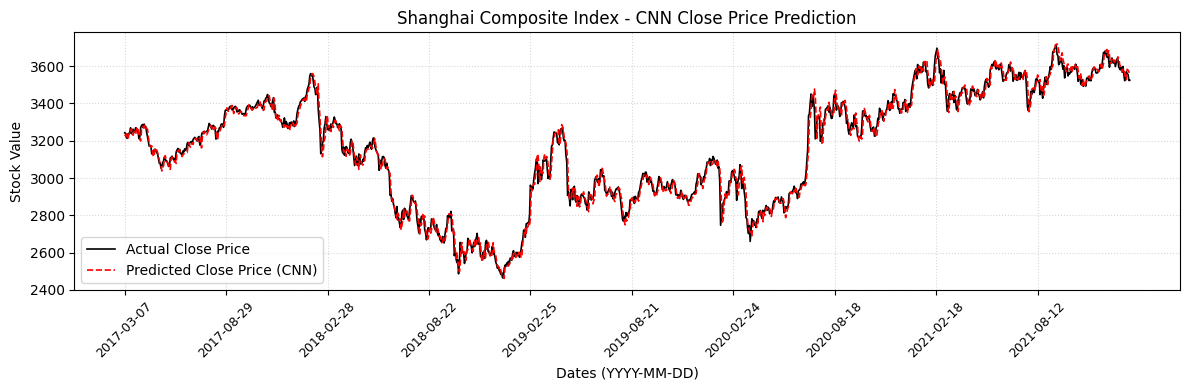

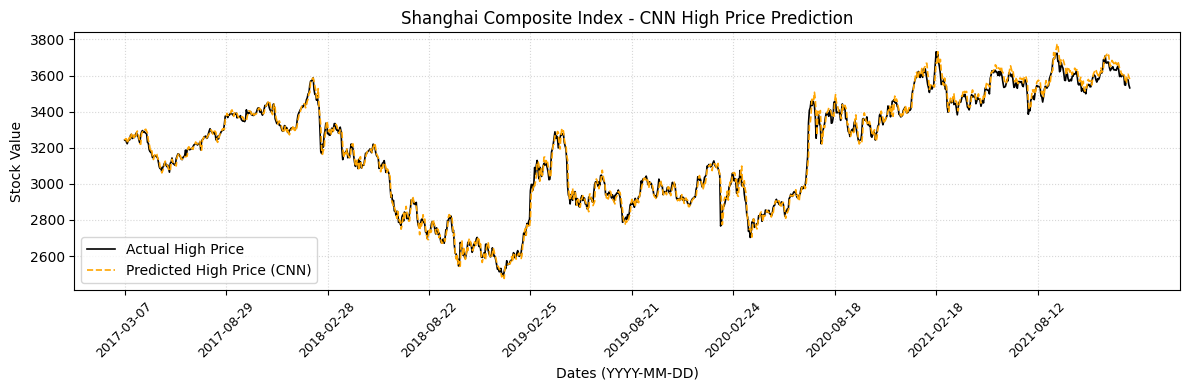

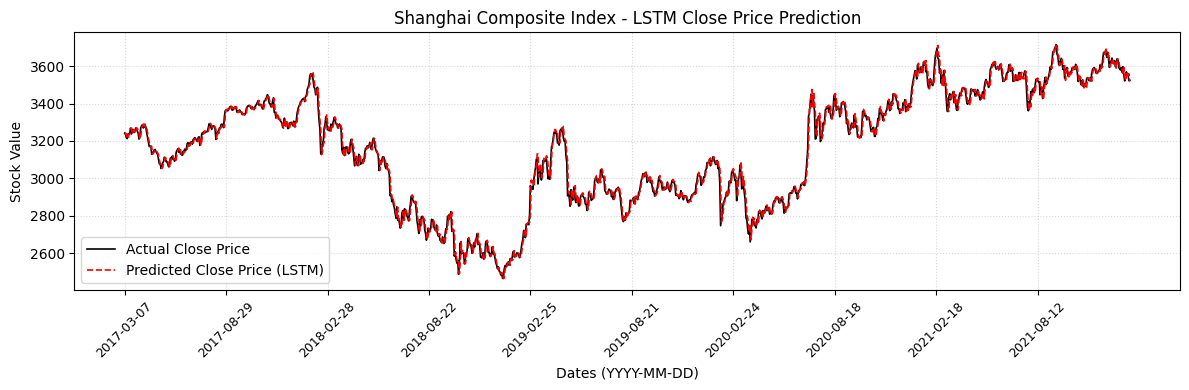

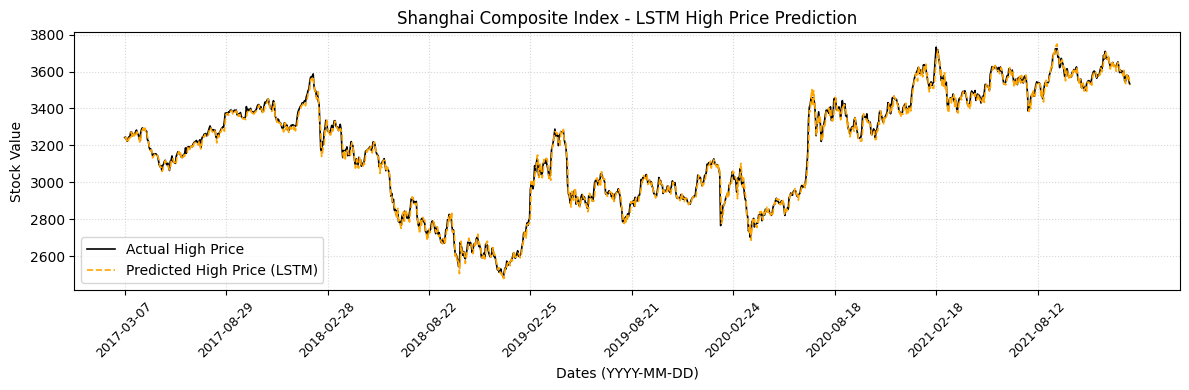

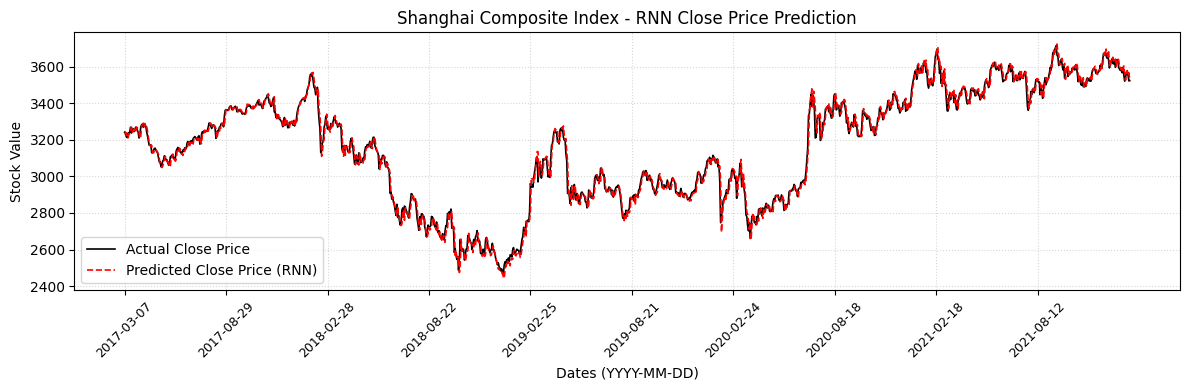

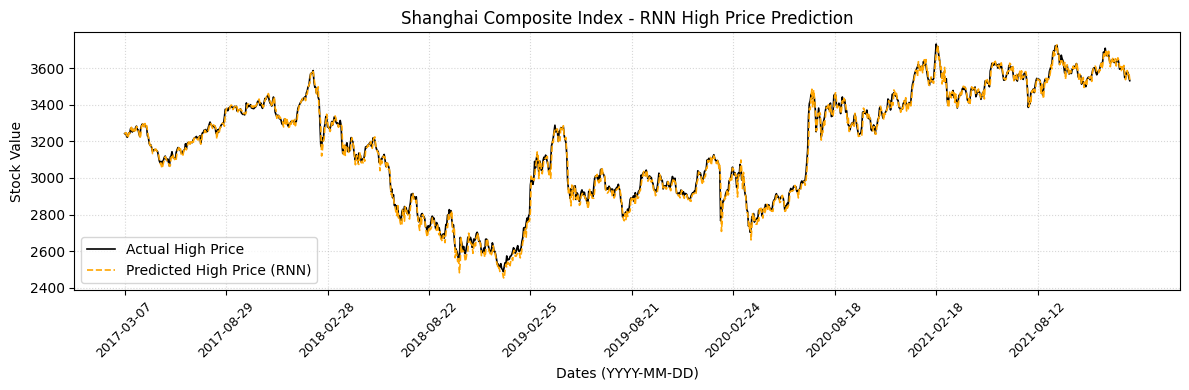

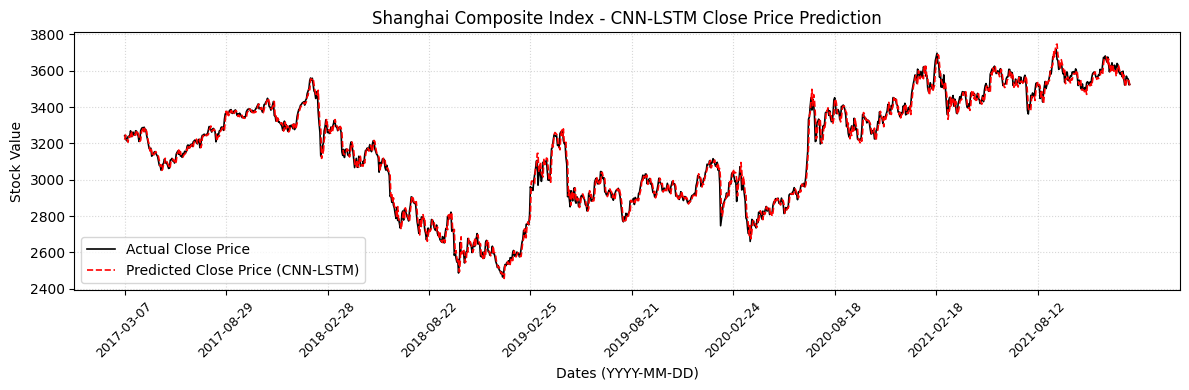

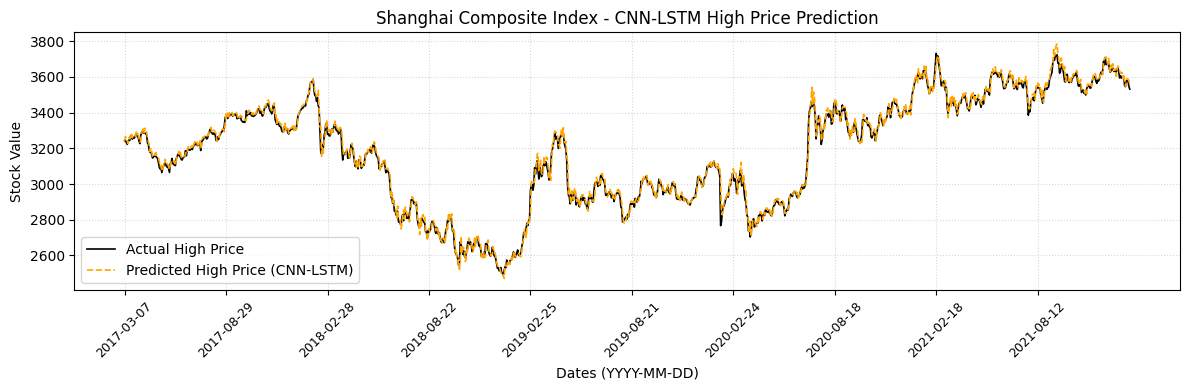

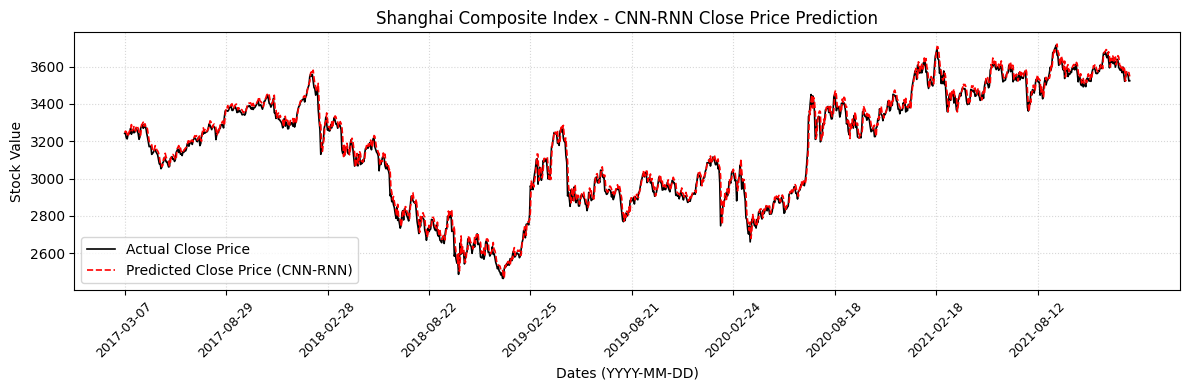

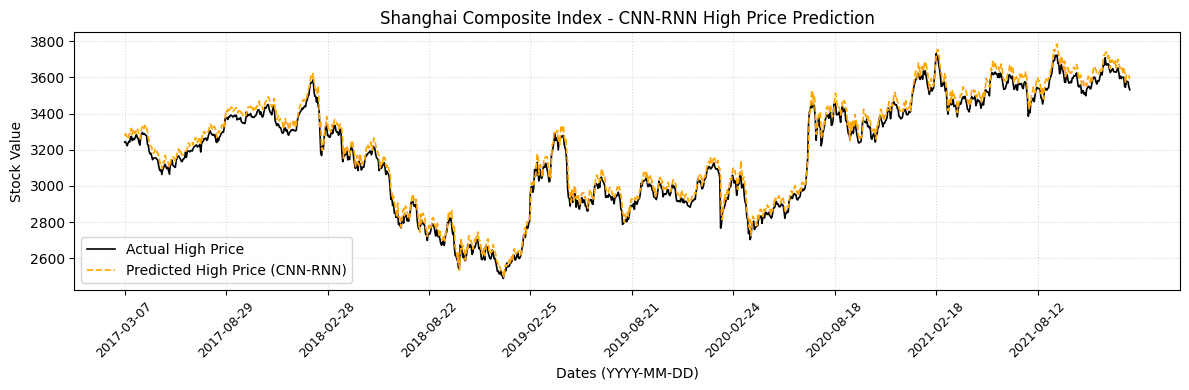

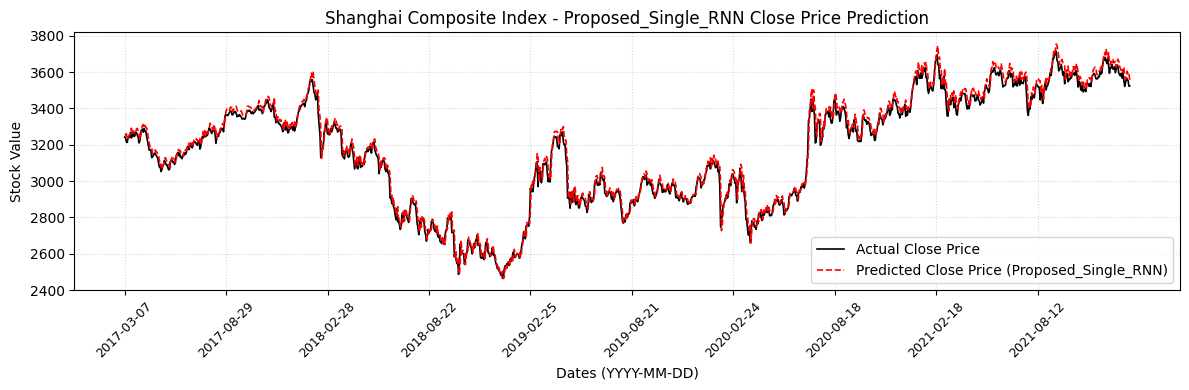

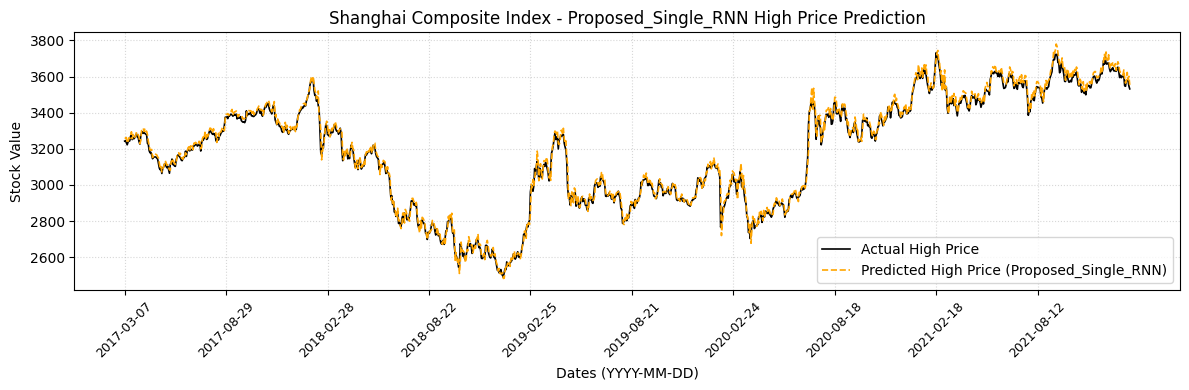

In [ ]:
# ==========================================
# 6. GENERATE THE 12 PREDICTION TRACKING PLOTS
# ==========================================

print("Generating the 12 Prediction Tracking Plots for the Two-Parameter Scenario...")

# We extract the metrics sequence recorded during the training cell
scenario = "two_parameter"

for m_type in model_types:
    dates = plot_data[scenario][m_type]["dates"]
    true_vals = plot_data[scenario][m_type]["true"]
    pred_vals = plot_data[scenario][m_type]["pred"]

    # ----------------------------------------------------
    # Plot A: Close Price Tracking (Figures 8, 10, 12, 14, 16, 18)
    # ----------------------------------------------------
    plt.figure(figsize=(12, 4))
    # In our extracted two_parameter array: index 0 is High, index 1 is Close
    plt.plot(dates, true_vals[:, 1], label='Actual Close Price', color='black', linewidth=1.2)
    plt.plot(dates, pred_vals[:, 1], label=f'Predicted Close Price ({m_type})', color='red', linestyle='--', linewidth=1.2)

    plt.title(f'Shanghai Composite Index - {m_type} Close Price Prediction')
    plt.xlabel('Dates (YYYY-MM-DD)')
    plt.ylabel('Stock Value')
    plt.xticks(range(0, len(dates), 120), rotation=45, fontsize=9)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------
    # Plot B: High Price Tracking (Figures 9, 11, 13, 15, 17, 19)
    # ----------------------------------------------------
    plt.figure(figsize=(12, 4))
    plt.plot(dates, true_vals[:, 0], label='Actual High Price', color='black', linewidth=1.2)
    plt.plot(dates, pred_vals[:, 0], label=f'Predicted High Price ({m_type})', color='orange', linestyle='--', linewidth=1.2)

    plt.title(f'Shanghai Composite Index - {m_type} High Price Prediction')
    plt.xlabel('Dates (YYYY-MM-DD)')
    plt.ylabel('Stock Value')
    plt.xticks(range(0, len(dates), 120), rotation=45, fontsize=9)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

Generating Evaluation Metrics Comparison Charts...


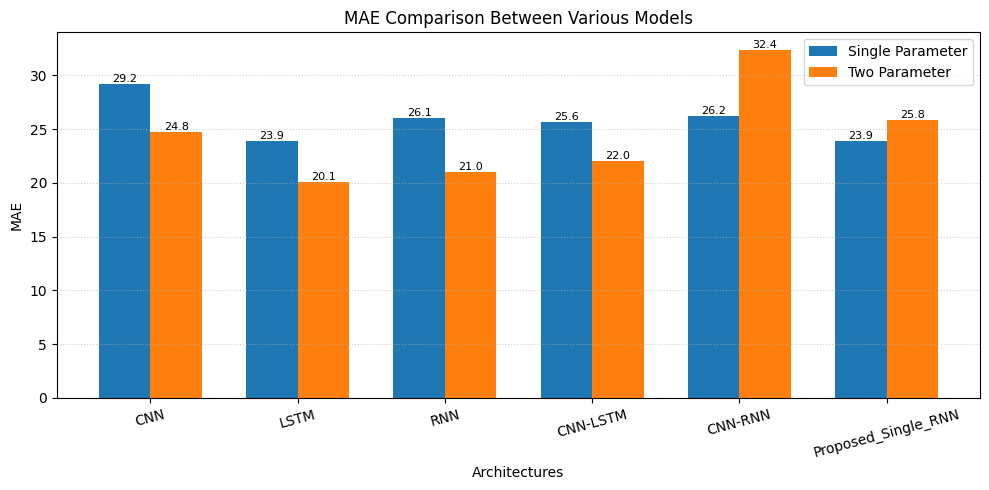

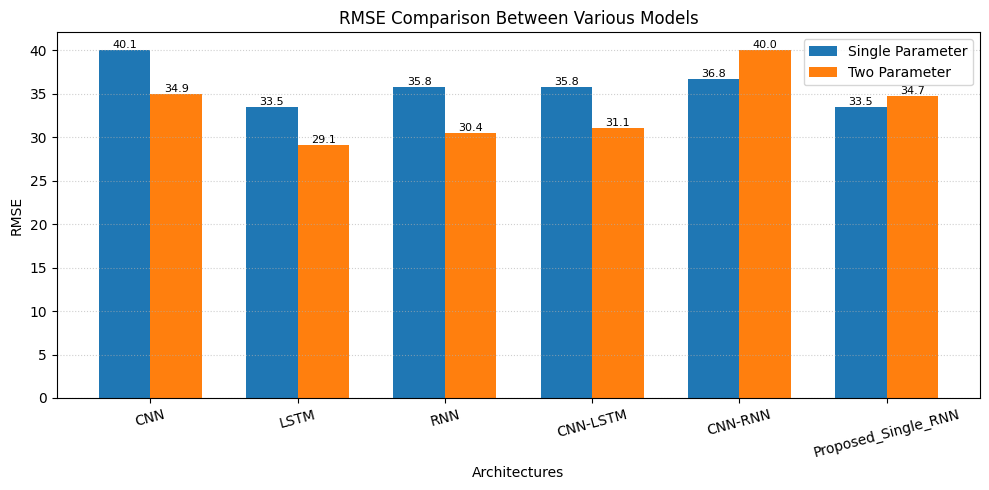

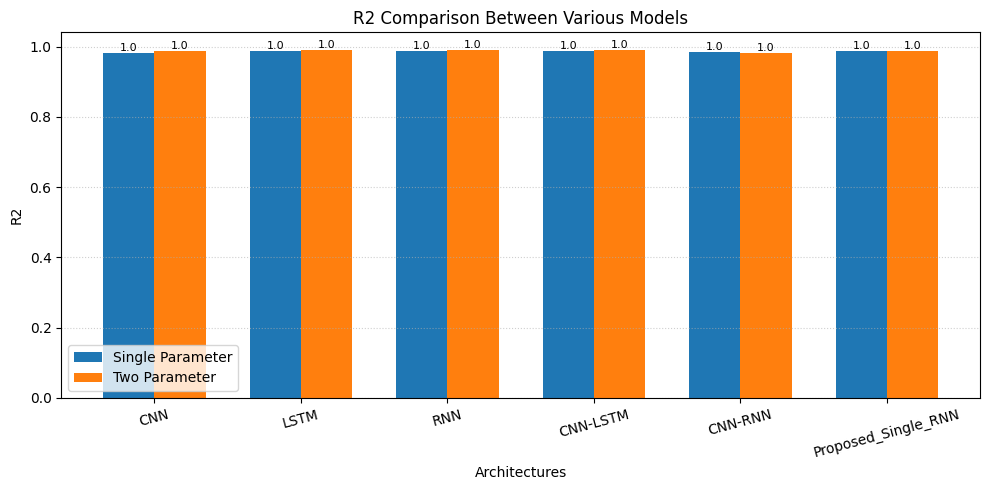

Replication pipeline completely finished.


In [ ]:
# ==========================================
# 7. GENERATE PERFORMANCE EVALUATION CHARTS
# ==========================================

print("Generating Evaluation Metrics Comparison Charts...")

# Extract values sequentially to match chart grouping
single_metrics = [summary_results["single_parameter"][m] for m in model_types]
two_metrics = [summary_results["two_parameter"][m] for m in model_types]

x = np.arange(len(model_types))
width = 0.35
metrics_list = ["MAE", "RMSE", "R2"]
colors = ['#1f77b4', '#ff7f0e']  # Blue for Single Parameter, Orange for Two Parameter

for metric in metrics_list:
    plt.figure(figsize=(10, 5))

    # Isolate metric values per model
    single_vals = [m[metric] for m in single_metrics]
    two_vals = [m[metric] for m in two_metrics]

    # Build bars side-by-side
    plt.bar(x - width/2, single_vals, width, label='Single Parameter', color=colors[0])
    plt.bar(x + width/2, two_vals, width, label='Two Parameter', color=colors[1])

    plt.title(f'{metric} Comparison Between Various Models')
    plt.xlabel('Architectures')
    plt.ylabel(metric)
    plt.xticks(x, model_types, rotation=15)
    plt.legend()
    plt.grid(True, axis='y', linestyle=':', alpha=0.6)

    # Attach data markers above bars
    for i in range(len(model_types)):
        plt.text(x[i] - width/2, single_vals[i], f'{single_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)
        plt.text(x[i] + width/2, two_vals[i], f'{two_vals[i]:.1f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

print("Replication pipeline completely finished.")

In [ ]:
# ==========================================
# 8. PRINT SAMPLE PREDICTIONS (TABLE 6)
# ==========================================

print("\n" + "="*85)
print("  SAMPLE TRACKING MATCH: ACTUAL VS PREDICTED (REPLICATING TABLE 6)")
print("="*85)
print(f"{'Date':<15} | {'Actual High':<12} | {'Actual Close':<12} | {'Pred High':<12} | {'Pred Close':<12}")
print("-" * 85)

# Extract arrays from our Proposed_Single_RNN test records under Two-Parameter
dates = plot_data["two_parameter"]["Proposed_Single_RNN"]["dates"]
true_vals = plot_data["two_parameter"]["Proposed_Single_RNN"]["true"]
pred_vals = plot_data["two_parameter"]["Proposed_Single_RNN"]["pred"]

# Find indices corresponding to the paper's target sample frame (March 2017 onwards)
sample_count = 0
for i, date_str in enumerate(dates):
    if "2017-03" in date_str:
        print(f"{date_str:<15} | {true_vals[i, 0]:<12.2f} | {true_vals[i, 1]:<12.2f} | {pred_vals[i, 0]:<12.2f} | {pred_vals[i, 1]:<12.2f}")
        sample_count += 1
        if sample_count >= 5:  # Print 5 trading days to match Table 6's layout structure
            break


  SAMPLE TRACKING MATCH: ACTUAL VS PREDICTED (REPLICATING TABLE 6)
Date            | Actual High  | Actual Close | Pred High    | Pred Close  
-------------------------------------------------------------------------------------
2017-03-07      | 3242.66      | 3242.41      | 3258.82      | 3253.17     
2017-03-08      | 3245.30      | 3240.67      | 3258.69      | 3254.68     
2017-03-09      | 3233.88      | 3216.75      | 3262.51      | 3261.53     
2017-03-10      | 3222.32      | 3212.76      | 3234.84      | 3232.77     
2017-03-13      | 3237.12      | 3237.02      | 3234.11      | 3233.25     
